**ITNPBD6-Machine Learning Assignment Autumn 2026**

**Telecom Customer Targeting**

**1. Data cleaning & Preprocessing**

1.1 Import "pandas" Library and Load dataset

In [1]:
import pandas as pd

In [98]:
df = pd.read_csv("wallacecommunications.csv")

In [99]:
df.shape

(50662, 20)

1.2 Inspect Data and Check Missing Values

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50662 entries, 0 to 50661
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         50662 non-null  int64  
 1   town                                       50662 non-null  object 
 2   country                                    50662 non-null  object 
 3   age                                        50662 non-null  int64  
 4   job                                        50662 non-null  object 
 5   married                                    50662 non-null  object 
 6   education                                  50662 non-null  object 
 7   arrears                                    50662 non-null  object 
 8   current_balance                            50662 non-null  float64
 9   housing                                    50662 non-null  object 
 10  has_tv_package        

In [101]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,yes
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,yes
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,yes
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,no
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,yes


1.3 Check for Duplicate Rows

In [102]:
df.duplicated().sum()

np.int64(0)

In [103]:
df.nunique()

,0
ID,50644
town,101
country,5
age,76
job,12
married,3
education,4
arrears,2
current_balance,6928
housing,2


1.4 Idendify Column Data Types

In [104]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("Categorical columns: ", cat_col)
print("Numerical columns: ", num_col)

Categorical columns:  ['town', 'country', 'job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign', 'new_contract_this_campaign']
Numerical columns:  ['ID', 'age', 'current_balance', 'conn_tr', 'last_contact_this_campaign_day', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign']


1.5 Convert Target to Numeric

In [105]:
df['target'] = df['new_contract_this_campaign'].map({'yes': 1, 'no': 0})

In [106]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,...,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign,target
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,...,unknown,4,11,jun,8,-1,0,unknown,yes,1
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,...,cellular,1,28,jul,2,-1,0,unknown,yes,1
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,...,telephone,3,13,jul,1,377,1,success,yes,1
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,...,cellular,3,13,may,2,-1,0,unknown,no,0
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,...,cellular,2,27,aug,16,-1,0,unknown,yes,1


1.6 Statistical Summary & Visualize Outliers

In [107]:
df.drop(columns=['ID', 'target']).describe().T

,count,mean,std,min,25%,50%,75%,max
age,50662.0,40.979373,10.919324,18.00,32.00,39.00,48.00,95.00
current_balance,50662.0,13.991210,30.899163,-80.19,0.82,4.72,14.95,984.17
conn_tr,50662.0,3.005093,1.409003,1.00,2.00,3.00,4.00,5.00
last_contact_this_campaign_day,50662.0,15.768525,8.347083,1.00,8.00,16.00,21.00,31.00
this_campaign,50662.0,2.713217,3.052227,1.00,1.00,2.00,3.00,63.00
days_since_last_contact_previous_campaign,50662.0,42.644408,102.238078,-1.00,-1.00,-1.00,-1.00,871.00
contacted_during_previous_campaign,50662.0,0.640283,2.358029,0.00,0.00,0.00,0.00,275.00


In [108]:
import matplotlib.pyplot as plt

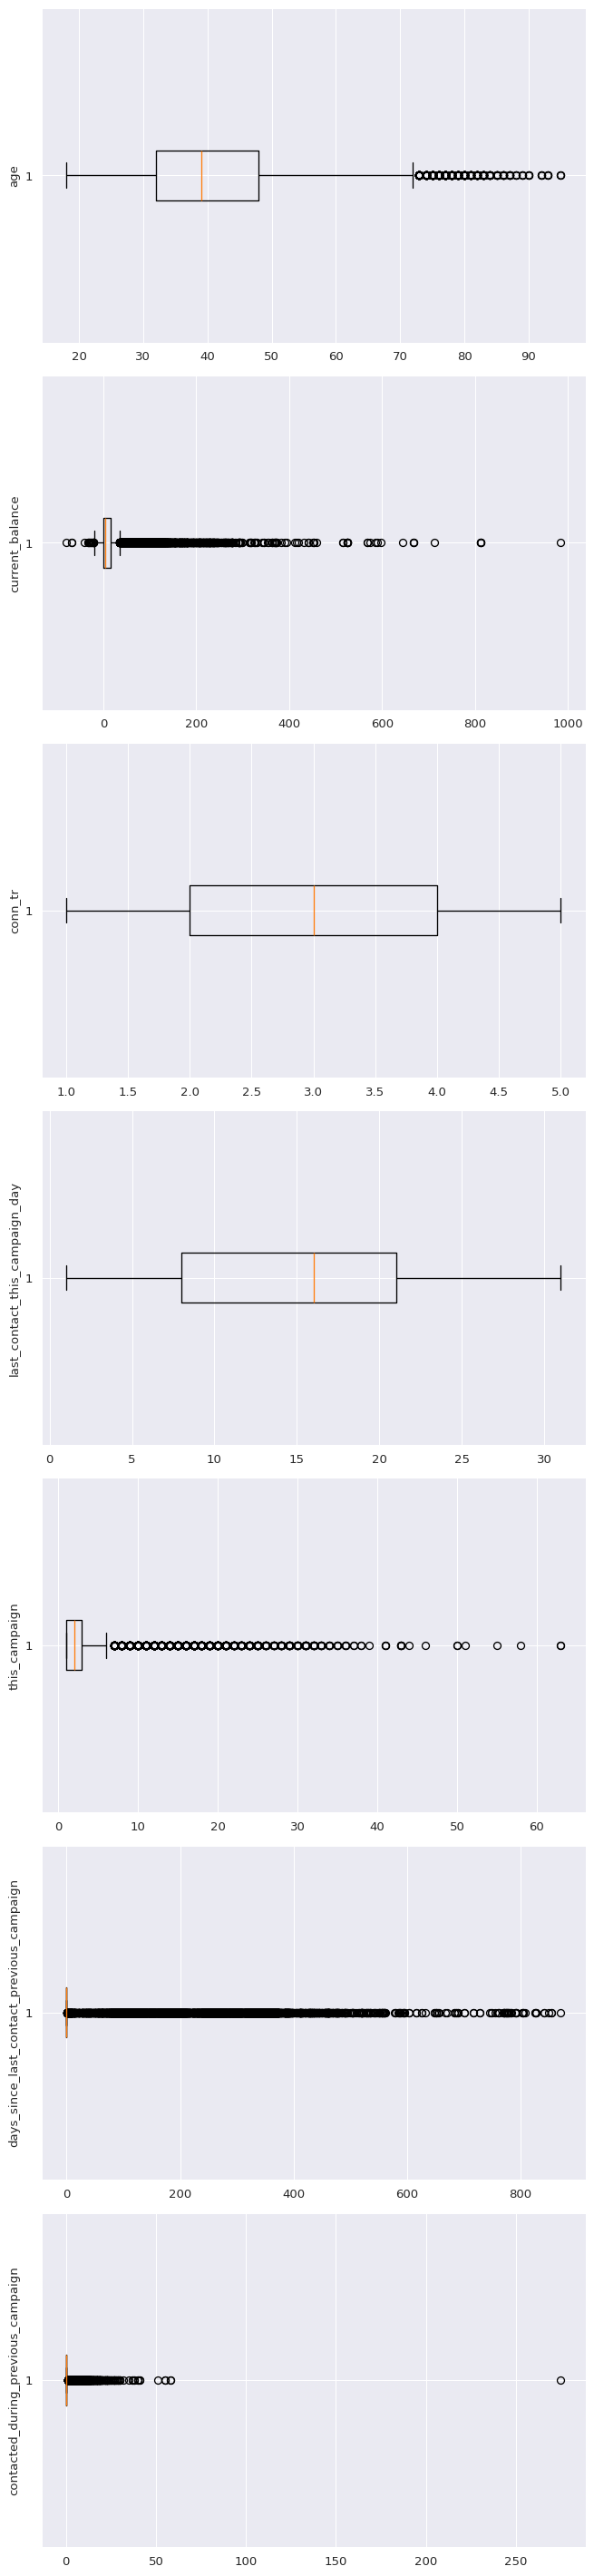

In [110]:
# Exclude ID
fix, axs = plt.subplots(len(num_col) - 1, 1, figsize=(7, 30), dpi=95)
for i, col in enumerate(num_col[1:]):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [93]:
# import numpy as np

# q1, q3 = np.percentile(df['contacted_during_previous_campaign'], [25, 75])
# iqr = q3 - q1
# print("Interquartile Range: ", iqr)

# lower_bound = q1 - 1.5*iqr
# upper_bound = q3 + 1.5*iqr

# df = df[(df['contacted_during_previous_campaign'] >= lower_bound) & (df['contacted_during_previous_campaign'] <= upper_bound)]

Interquartile Range:  0.0


In [111]:
# plt.boxplot(df['contacted_during_previous_campaign'], vert=False)
# plt.title('Box Plot For Age')
# plt.show()

1.7 Correlation Analysis

In [18]:
pip install seaborn

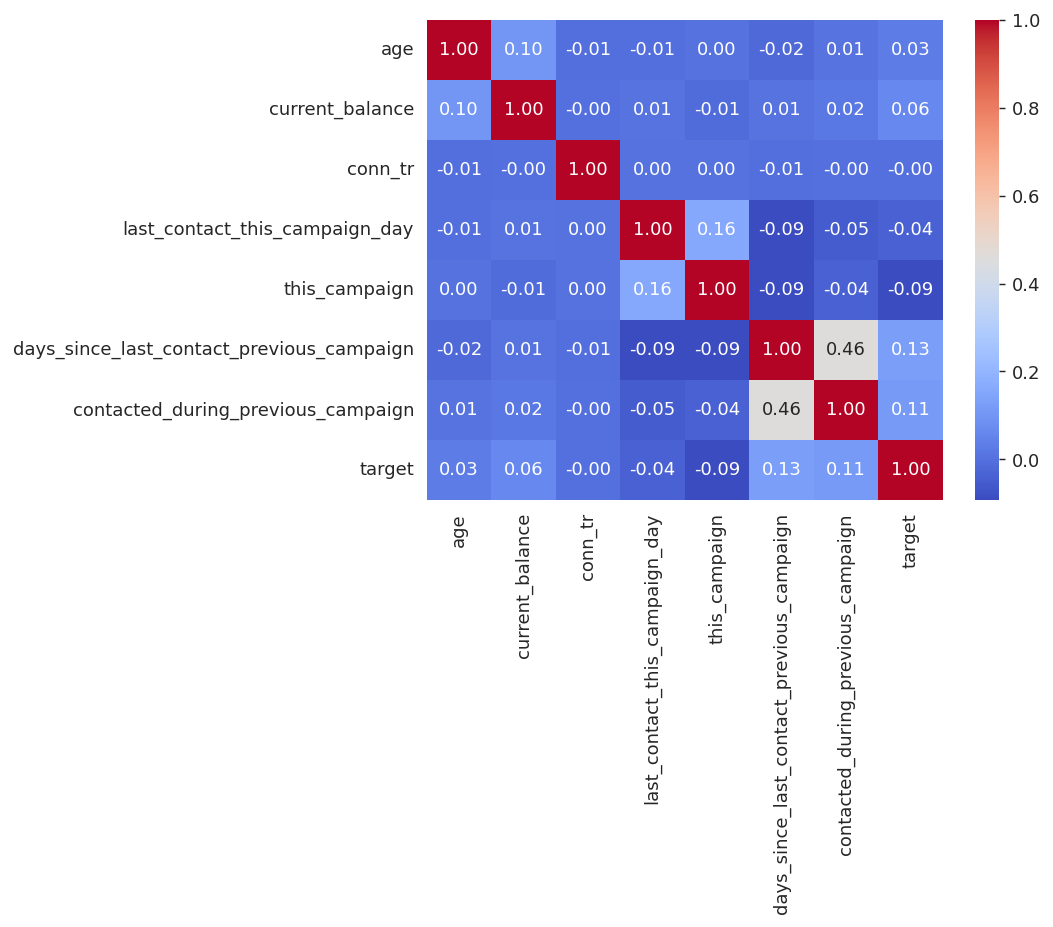

target                                       1.000000
days_since_last_contact_previous_campaign    0.126678
contacted_during_previous_campaign           0.112417
current_balance                              0.064008
age                                          0.030501
conn_tr                                     -0.002382
last_contact_this_campaign_day              -0.038615
this_campaign                               -0.091829
Name: target, dtype: float64


In [112]:
import seaborn as sns

df_corr = df.select_dtypes(include='number').drop(columns=['ID'])
corr = df_corr.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr["target"].sort_values(ascending=False))

Overall, the correlation analysis shows that the non of the numerical columns have strong linear relationships with target variable. With weak correlation, removing outliers will not impact on model prediction.



Kernel Density Plot to Understanding Variance in the Dataset

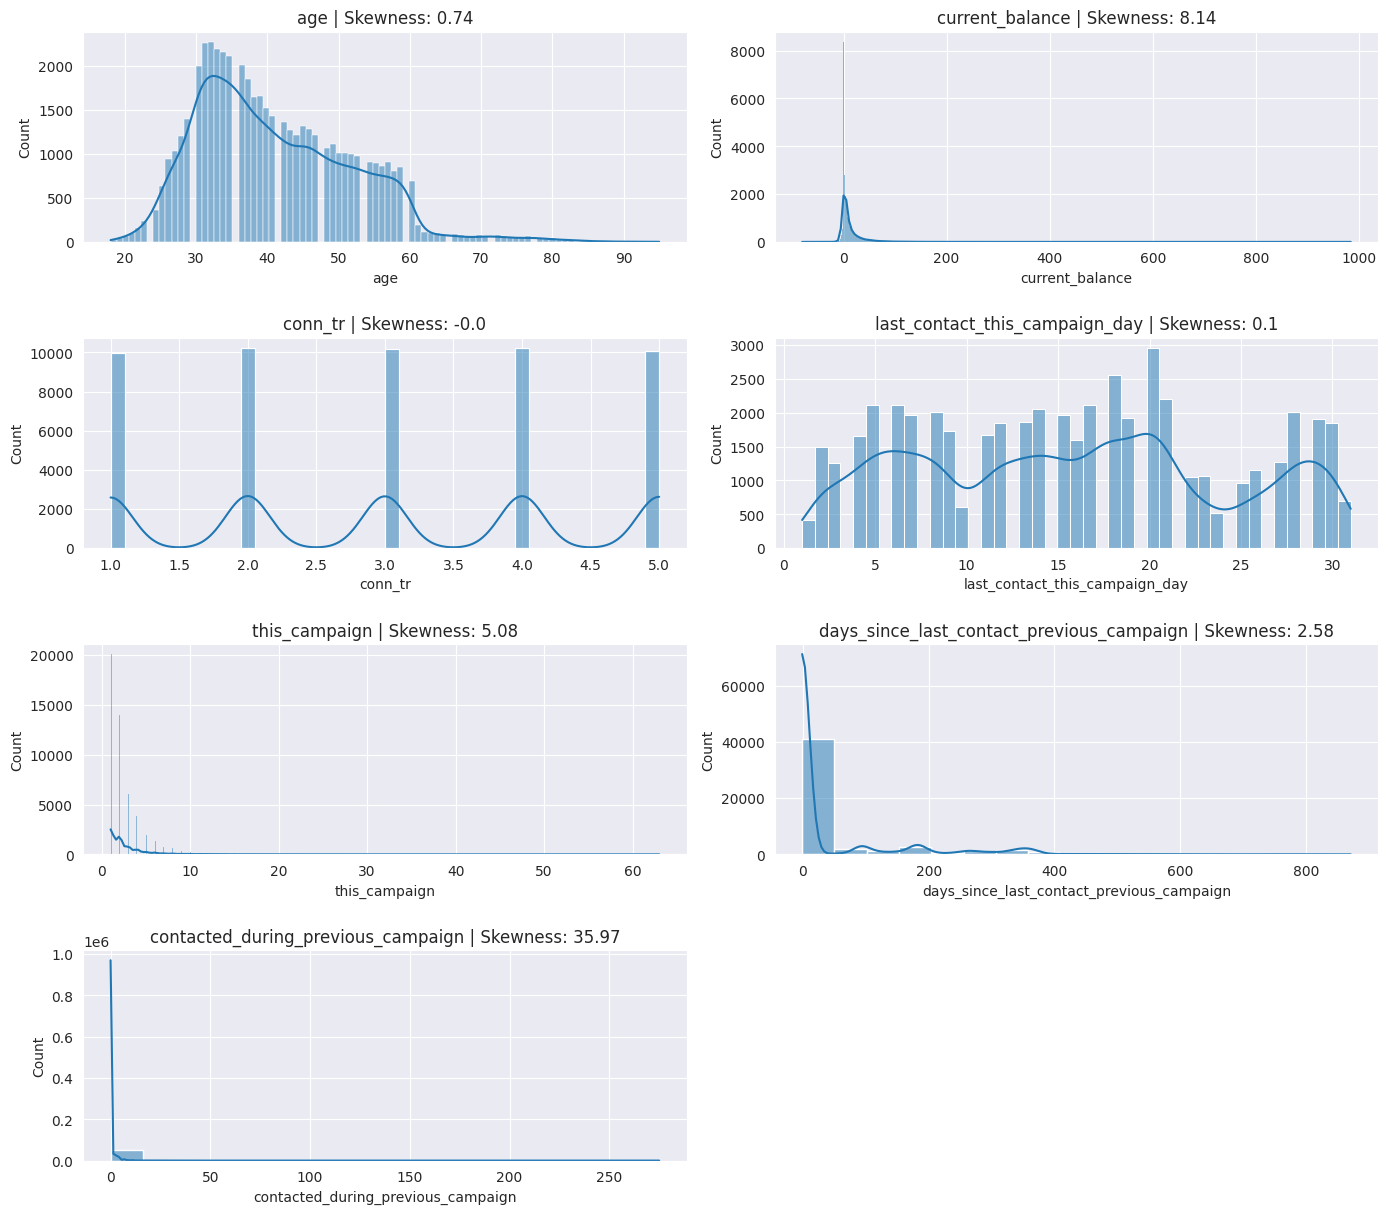

In [113]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include='number').columns[1:-1]

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

1.8 Visualize Target Variable Distribution

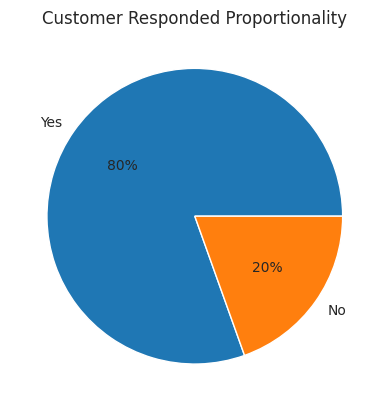

In [114]:
plt.pie(df['target'].value_counts(), labels=['Yes', 'No'], autopct='%.f%%')
plt.title('Customer Responded Proportionality')
plt.show()

1.9 Univariate Analysis

In [115]:
def display_bar_chart(col, figsize=(6, 4)):
  counts = df[col].value_counts()

  plt.figure(figsize=figsize)
  plt.bar(counts.index, counts, color='SteelBlue')
  plt.title(f'Count plot of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

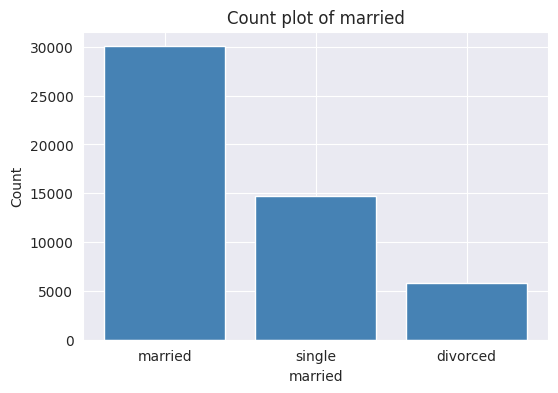

In [116]:
display_bar_chart('married')

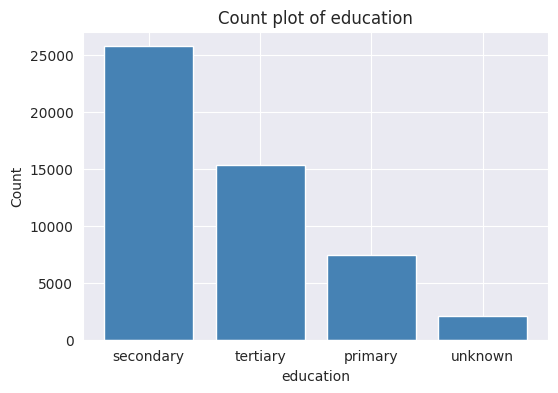

In [117]:
display_bar_chart('education')

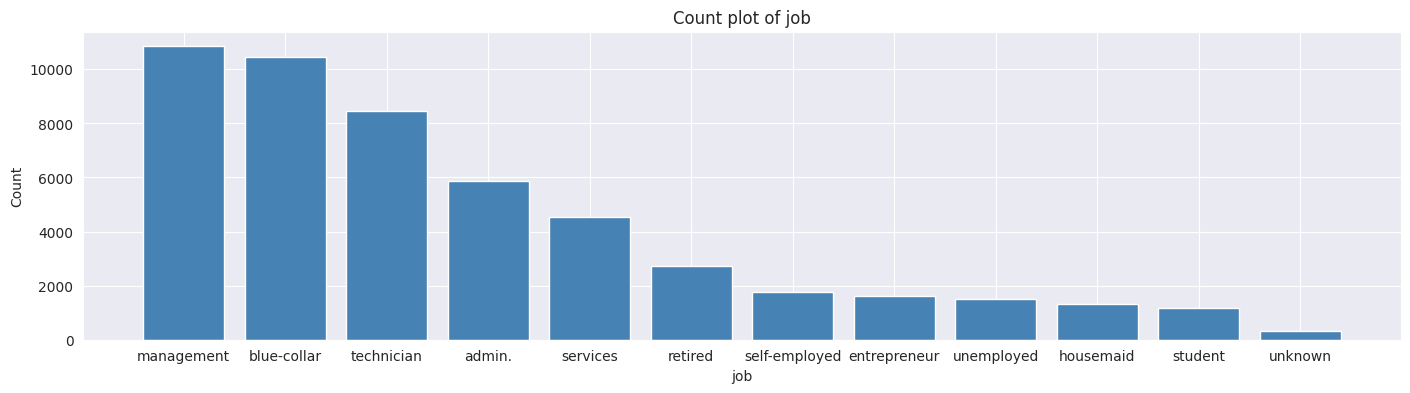

In [118]:
display_bar_chart('job', (17, 4))